In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.applications import ResNet50, Xception, EfficientNetV2S, VGG16
from tensorflow.keras.layers import Dense, Flatten
from sklearn.metrics import classification_report
import warnings
from sklearn.metrics import (
    confusion_matrix, classification_report, accuracy_score, precision_score,
    recall_score, f1_score, roc_auc_score, matthews_corrcoef, cohen_kappa_score
)
import seaborn as sns
warnings.filterwarnings("ignore")

## Load dataset
dataset contains pf header info

This dataset contains headers of 1986 binary executable 

In [2]:
df = pd.read_csv('pe_headers.csv')

In [3]:
# preview data
df.head()

,GR,0,1,2,3,4,5,6,7,8,...,1014,1015,1016,1017,1018,1019,1020,1021,1022,1023
0,0,77,90,144,0,3,0,0,0,4,...,0,0,0,0,0,0,0,0,0,0
1,0,77,90,144,0,3,0,0,0,4,...,0,0,0,0,0,0,0,0,0,0
2,0,77,90,144,0,3,0,0,0,4,...,0,0,0,0,0,0,0,0,0,0
3,0,77,90,144,0,3,0,0,0,4,...,0,0,0,0,0,0,0,0,0,0
4,0,77,90,144,0,3,0,0,0,4,...,0,0,0,0,0,0,0,0,0,0


In [4]:
# PE Header 1024
df.iloc[:, 1:]

,0,1,2,3,4,5,6,7,8,9,...,1014,1015,1016,1017,1018,1019,1020,1021,1022,1023
0,77,90,144,0,3,0,0,0,4,0,...,0,0,0,0,0,0,0,0,0,0
1,77,90,144,0,3,0,0,0,4,0,...,0,0,0,0,0,0,0,0,0,0
2,77,90,144,0,3,0,0,0,4,0,...,0,0,0,0,0,0,0,0,0,0
3,77,90,144,0,3,0,0,0,4,0,...,0,0,0,0,0,0,0,0,0,0
4,77,90,144,0,3,0,0,0,4,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1980,77,90,144,0,3,0,0,0,4,0,...,0,0,0,0,0,0,0,0,0,0
1981,77,90,144,0,3,0,0,0,4,0,...,0,0,0,0,0,0,0,0,0,0
1982,77,90,144,0,3,0,0,0,4,0,...,0,0,0,0,0,0,0,0,0,0
1983,77,90,144,0,3,0,0,0,4,0,...,0,0,0,0,0,0,0,0,0,0


In [5]:
df.sample(9,random_state=42)

,GR,0,1,2,3,4,5,6,7,8,...,1014,1015,1016,1017,1018,1019,1020,1021,1022,1023
582,0,77,90,80,0,2,0,0,0,4,...,0,0,0,0,0,0,0,0,0,0
1711,1,77,90,80,0,2,0,0,0,4,...,0,0,0,0,0,0,0,0,0,0
1052,1,77,90,144,0,3,0,0,0,4,...,0,0,0,0,0,0,0,0,0,0
1075,1,77,90,144,0,3,0,0,0,4,...,0,0,0,0,0,0,0,0,0,0
917,0,77,90,80,0,2,0,0,0,4,...,0,0,0,0,0,0,0,0,0,0
70,0,77,90,80,0,2,0,0,0,4,...,0,0,0,0,0,0,0,0,0,0
429,0,77,90,144,0,3,0,0,0,4,...,5,0,0,50,17,0,38,17,0,221
903,0,77,90,144,0,3,0,0,0,4,...,0,0,0,0,0,0,0,0,0,0
914,0,77,90,144,0,3,0,0,0,4,...,0,0,0,0,0,0,0,0,0,0


### Plot sample images

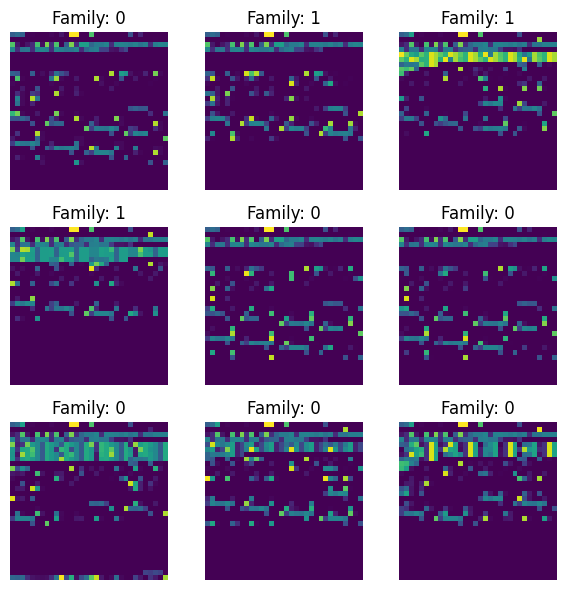

In [6]:
samp  = df.sample(9,random_state=42)
# Convert the numerical columns to color images
samp_images = samp.iloc[:, 1:].values.reshape(-1, 32, 32,1)
# Normalize the image values to [0, 1]
samp_images = samp_images / 255.0

# Create a new figure and plot the images
fig, axes = plt.subplots(3, 3, figsize=(6, 6))

# Flatten the axes array to make it easier to iterate over
axes = axes.flatten()

# Iterate over each image and plot it
for i in range(len(axes)):
    ax = axes[i]
    ax.imshow(samp_images[i], cmap='viridis')  # Assuming grayscale images
    ax.axis('off')  # Turn off axis labels
    ax.set_title(f'Family: {samp.iloc[i, 0]}')

plt.tight_layout()  # Adjust layout to prevent overlap
plt.show()

## Convert to colored and Split data

In [19]:
# Split the data into training and validation sets (70% for training, 20% for validation, 10% for test)
train_df, val_df = train_test_split(df, test_size=0.3, random_state=42)
val_df, test_df = train_test_split(val_df, test_size=1/3, random_state=42)

# Convert the numerical columns to image
train_images = train_df.iloc[:, 1:].values.reshape(-1, 32, 32,1)
val_images = val_df.iloc[:, 1:].values.reshape(-1, 32, 32,1)
test_images = test_df.iloc[:, 1:].values.reshape(-1, 32, 32,1)

# Normalize the image values to [0, 1]
train_images = train_images / 255.0
val_images = val_images / 255.0
test_images = test_images / 255.0

# Convert the numerical columns to color images
train_images = np.repeat(train_images, 3, axis=3)
val_images = np.repeat(val_images, 3, axis=3)
test_images = np.repeat(test_images, 3, axis=3)

In [20]:
# Reshape each image in train_images to (256, 256, 3)
train_images = tf.image.resize(train_images, (256, 256))

# Reshape each image in val_images to (256, 256, 3)
val_images = tf.image.resize(val_images, (256, 256))

# Reshape each image in test_images to (256, 256, 3)
test_images = tf.image.resize(test_images, (256, 256))

## Build Resnet model for Goodware and randsomeware detection

In [21]:
# get target label
train_labels = train_df['GR'].values
val_labels = val_df['GR'].values
test_labels = test_df['GR'].values

In [22]:
# Define the ResNet model
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(256, 256, 3))

# Flatten the output from the base model
x = Flatten()(base_model.output)

# Add a dense layer with 26 units for classification
x = Dense(128, activation='relu')(x)
x = Dense(64, activation='relu')(x)
x = Dense(1, activation='sigmoid')(x) #Dense(2, activation='softmax')(x)

# Define the model
model = tf.keras.Model(inputs=base_model.input, outputs=x)

# Freeze some layers
for layer in base_model.layers:
    layer.trainable = False

In [23]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [24]:
model.fit(train_images, train_labels, epochs=35, validation_data=(val_images, val_labels))

Epoch 1/35
44/44 ━━━━━━━━━━━━━━━━━━━━ 137s 3s/step - accuracy: 0.5124 - loss: 3.7340 - val_accuracy: 0.7218 - val_loss: 0.5845
Epoch 2/35
44/44 ━━━━━━━━━━━━━━━━━━━━ 118s 3s/step - accuracy: 0.5945 - loss: 0.7497 - val_accuracy: 0.7368 - val_loss: 0.5462
Epoch 3/35
44/44 ━━━━━━━━━━━━━━━━━━━━ 118s 3s/step - accuracy: 0.6405 - loss: 0.6478 - val_accuracy: 0.7368 - val_loss: 0.5349
Epoch 4/35
44/44 ━━━━━━━━━━━━━━━━━━━━ 123s 3s/step - accuracy: 0.6979 - loss: 0.5911 - val_accuracy: 0.7694 - val_loss: 0.5334
Epoch 5/35
44/44 ━━━━━━━━━━━━━━━━━━━━ 120s 3s/step - accuracy: 0.7109 - loss: 0.5618 - val_accuracy: 0.5464 - val_loss: 0.8506
Epoch 6/35
44/44 ━━━━━━━━━━━━━━━━━━━━ 120s 3s/step - accuracy: 0.7228 - loss: 0.5663 - val_accuracy: 0.7694 - val_loss: 0.5271
Epoch 7/35
44/44 ━━━━━━━━━━━━━━━━━━━━ 119s 3s/step - accuracy: 0.7625 - loss: 0.4835 - val_accuracy: 0.6591 - val_loss: 0.6779
Epoch 8/35
44/44 ━━━━━━━━━━━━━━━━━━━━ 122s 3s/step - accuracy: 0.6832 - loss: 0.6088 - val_accuracy: 0.5714 - v

In [25]:
# Evaluate the model on the validation set
y_pred = model.predict(test_images)

7/7 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step


In [26]:
# Convert the predictions to labels (0 or 1)
y_pred_labels = (y_pred > 0.5).astype(int)

# Get the true labels
y_true = test_labels

# Print the classification report
print(classification_report(y_true, y_pred_labels,target_names=['Goodware','Ransomeware']))

              precision    recall  f1-score   support

    Goodware       0.84      0.88      0.86        89
 Ransomeware       0.89      0.86      0.88       108

    accuracy                           0.87       197
   macro avg       0.87      0.87      0.87       197
weighted avg       0.87      0.87      0.87       197



In [27]:
# Confusion matrix
cm = confusion_matrix(y_true, y_pred_labels)
tn, fp, fn, tp = cm.ravel()

# Precision
precision = precision_score(y_true, y_pred_labels)

# Recall
recall = recall_score(y_true, y_pred_labels)

# Accuracy
accuracy = accuracy_score(y_true, y_pred_labels)

# FN rate (False Negative Rate)
fn_rate = fn / (fn + tp)

# FP rate (False Positive Rate)
fp_rate = fp / (fp + tn)

# F-measure
f_measure = f1_score(y_true, y_pred_labels)

# Error rate
error_rate = 1 - accuracy

# Matthews Correlation Coefficient (MCC)
mcc = matthews_corrcoef(y_true, y_pred_labels)

# Kappa
kappa = cohen_kappa_score(y_true, y_pred_labels)

# AUC-ROC
auc_roc = roc_auc_score(y_true, y_pred)

# Print the classification report
print(classification_report(y_true, y_pred_labels, target_names=['Goodware', 'Ransomeware']))

# Print all the metrics
print(f"Confusion Matrix: \n{cm}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"Accuracy: {accuracy:.4f}")
print(f"FN Rate: {fn_rate:.4f}")
print(f"FP Rate: {fp_rate:.4f}")
print(f"F-measure: {f_measure:.4f}")
print(f"Error Rate: {error_rate:.4f}")
print(f"MCC: {mcc:.4f}")
print(f"Kappa: {kappa:.4f}")
print(f"AUC-ROC: {auc_roc:.4f}")

              precision    recall  f1-score   support

    Goodware       0.84      0.88      0.86        89
 Ransomeware       0.89      0.86      0.88       108

    accuracy                           0.87       197
   macro avg       0.87      0.87      0.87       197
weighted avg       0.87      0.87      0.87       197

Confusion Matrix: 
[[78 11]
 [15 93]]
Precision: 0.8942
Recall: 0.8611
Accuracy: 0.8680
FN Rate: 0.1389
FP Rate: 0.1236
F-measure: 0.8774
Error Rate: 0.1320
MCC: 0.7352
Kappa: 0.7346
AUC-ROC: 0.9454


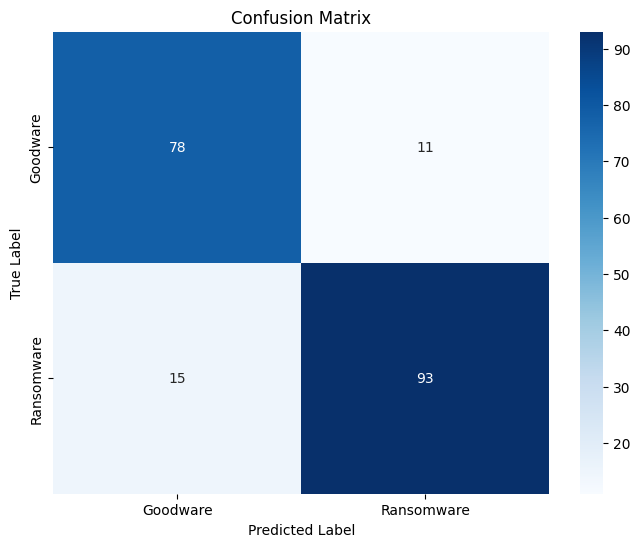

In [28]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Goodware', 'Ransomware'], yticklabels=['Goodware', 'Ransomware'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [29]:
lines = classification_report(y_true, y_pred_labels).split('\n')
recall_scores = [float(line.split()[2]) for line in lines[2:4]]

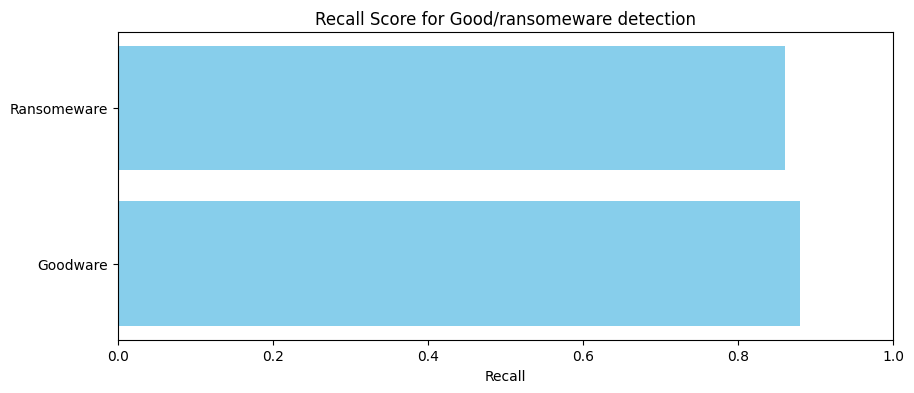

In [30]:
plt.figure(figsize=(10, 4))
plt.barh(['Goodware','Ransomeware'], recall_scores, color='skyblue')
plt.xlabel('Recall')
plt.title('Recall Score for Good/ransomeware detection')
plt.xlim(0, 1)  # Set x-axis limit to ensure consistency
plt.show()

## Build Xception model for Goodware/Ransomeware detection

In [31]:
# get target label
train_labels = train_df['GR'].values
val_labels = val_df['GR'].values
test_labels = test_df['GR'].values

In [32]:
# Define the ResNet model
base_model = Xception(weights='imagenet', include_top=False, input_shape=(256, 256, 3))

# Flatten the output from the base model
x = Flatten()(base_model.output)

# Add a dense layer with 26 units for classification
x = Dense(256, activation='relu')(x)
x = Dense(128, activation='relu')(x)
x = Dense(64, activation='relu')(x)
x = Dense(1, activation='sigmoid')(x) #Dense(2, activation='softmax')(x)

# Define the model
model_xception = tf.keras.Model(inputs=base_model.input, outputs=x)

# Freeze some layers
for layer in base_model.layers:
    layer.trainable = False

In [33]:
# Compile the model
model_xception.compile(optimizer='Adam', loss='binary_crossentropy', metrics=['accuracy'])

In [34]:
# train model
model_xception.fit(train_images, train_labels, epochs=15, validation_data=(val_images, val_labels))

Epoch 1/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 161s 4s/step - accuracy: 0.5750 - loss: 2.8189 - val_accuracy: 0.7519 - val_loss: 0.7047
Epoch 2/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 160s 4s/step - accuracy: 0.7759 - loss: 0.5550 - val_accuracy: 0.8246 - val_loss: 0.5162
Epoch 3/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 156s 4s/step - accuracy: 0.8372 - loss: 0.4256 - val_accuracy: 0.8521 - val_loss: 0.3775
Epoch 4/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 157s 4s/step - accuracy: 0.8775 - loss: 0.2743 - val_accuracy: 0.8521 - val_loss: 0.3614
Epoch 5/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 156s 4s/step - accuracy: 0.9349 - loss: 0.1644 - val_accuracy: 0.8496 - val_loss: 0.4309
Epoch 6/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 156s 4s/step - accuracy: 0.9323 - loss: 0.1734 - val_accuracy: 0.8120 - val_loss: 0.5727
Epoch 7/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 157s 4s/step - accuracy: 0.8980 - loss: 0.2723 - val_accuracy: 0.8596 - val_loss: 0.3526
Epoch 8/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 156s 4s/step - accuracy: 0.9527 - loss: 0.1056 - val_accuracy: 0.8747 - v

In [35]:
# Evaluate the model on the validation set
y_pred = model_xception.predict(test_images)

7/7 ━━━━━━━━━━━━━━━━━━━━ 19s 2s/step


In [36]:
# Convert the predictions to labels (0 or 1)
y_pred_labels = (y_pred > 0.5).astype(int)

# Get the true labels
y_true = test_labels

# Print the classification report
print(classification_report(y_true, y_pred_labels,target_names=['Goodware','Ransomeware']))

              precision    recall  f1-score   support

    Goodware       0.86      0.96      0.90        89
 Ransomeware       0.96      0.87      0.91       108

    accuracy                           0.91       197
   macro avg       0.91      0.91      0.91       197
weighted avg       0.91      0.91      0.91       197



In [37]:
# Confusion matrix
cm = confusion_matrix(y_true, y_pred_labels)
tn, fp, fn, tp = cm.ravel()

# Precision
precision = precision_score(y_true, y_pred_labels)

# Recall
recall = recall_score(y_true, y_pred_labels)

# Accuracy
accuracy = accuracy_score(y_true, y_pred_labels)

# FN rate (False Negative Rate)
fn_rate = fn / (fn + tp)

# FP rate (False Positive Rate)
fp_rate = fp / (fp + tn)

# F-measure
f_measure = f1_score(y_true, y_pred_labels)

# Error rate
error_rate = 1 - accuracy

# Matthews Correlation Coefficient (MCC)
mcc = matthews_corrcoef(y_true, y_pred_labels)

# Kappa
kappa = cohen_kappa_score(y_true, y_pred_labels)

# AUC-ROC
auc_roc = roc_auc_score(y_true, y_pred)

# Print the classification report
print(classification_report(y_true, y_pred_labels, target_names=['Goodware', 'Ransomeware']))

# Print all the metrics
print(f"Confusion Matrix: \n{cm}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"Accuracy: {accuracy:.4f}")
print(f"FN Rate: {fn_rate:.4f}")
print(f"FP Rate: {fp_rate:.4f}")
print(f"F-measure: {f_measure:.4f}")
print(f"Error Rate: {error_rate:.4f}")
print(f"MCC: {mcc:.4f}")
print(f"Kappa: {kappa:.4f}")
print(f"AUC-ROC: {auc_roc:.4f}")

              precision    recall  f1-score   support

    Goodware       0.86      0.96      0.90        89
 Ransomeware       0.96      0.87      0.91       108

    accuracy                           0.91       197
   macro avg       0.91      0.91      0.91       197
weighted avg       0.91      0.91      0.91       197

Confusion Matrix: 
[[85  4]
 [14 94]]
Precision: 0.9592
Recall: 0.8704
Accuracy: 0.9086
FN Rate: 0.1296
FP Rate: 0.0449
F-measure: 0.9126
Error Rate: 0.0914
MCC: 0.8216
Kappa: 0.8173
AUC-ROC: 0.9627


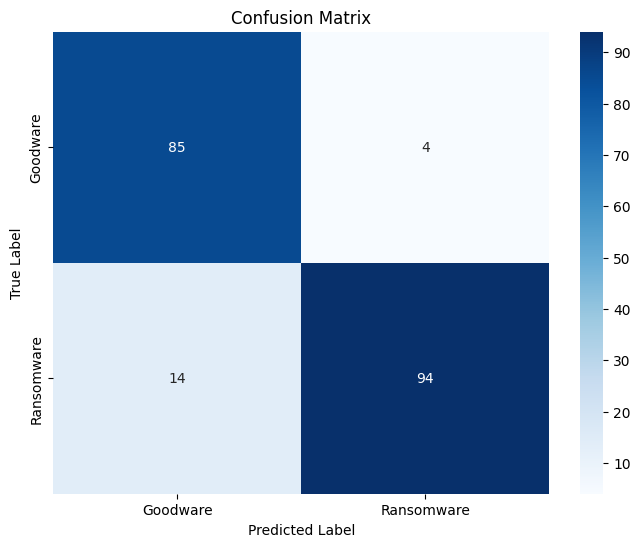

In [38]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Goodware', 'Ransomware'], yticklabels=['Goodware', 'Ransomware'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

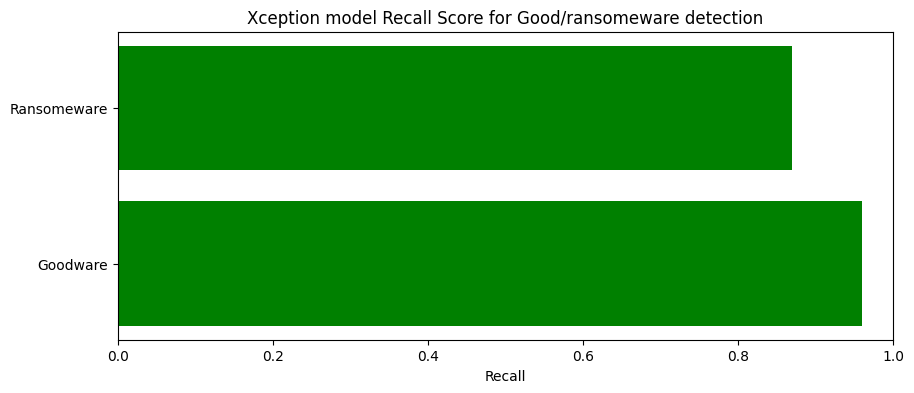

In [39]:
lines = classification_report(y_true, y_pred_labels).split('\n')
recall_scores = [float(line.split()[2]) for line in lines[2:4]]

plt.figure(figsize=(10, 4))
plt.barh(['Goodware','Ransomeware'], recall_scores, color='green')
plt.xlabel('Recall')
plt.title('Xception model Recall Score for Good/ransomeware detection')
plt.xlim(0, 1)  # Set x-axis limit to ensure consistency
plt.show()

## Build VGG16 model for Goodware/Ransomeware detection

In [40]:
# get target label
train_labels = train_df['GR'].values
val_labels = val_df['GR'].values
test_labels = test_df['GR'].values

In [41]:
# Define the ResNet model
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(256, 256, 3))

# Flatten the output from the base model
x = Flatten()(base_model.output)

# Add a dense layer with 26 units for classification
x = Dense(128, activation='relu')(x)
x = Dense(64, activation='relu')(x)
x = Dense(1, activation='sigmoid')(x) #Dense(2, activation='softmax')(x)

# Define the model
model_VGG = tf.keras.Model(inputs=base_model.input, outputs=x)

# Freeze some layers
for layer in base_model.layers:
    layer.trainable = False

In [47]:
# Compile the model
model_VGG.compile(optimizer='Adam', loss='binary_crossentropy', metrics=['accuracy'])

In [48]:
# train model
model_VGG.fit(train_images, train_labels, epochs=20, validation_data=(val_images, val_labels))

Epoch 1/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 364s 8s/step - accuracy: 0.8765 - loss: 0.2631 - val_accuracy: 0.8697 - val_loss: 0.3012
Epoch 2/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 380s 9s/step - accuracy: 0.9260 - loss: 0.1732 - val_accuracy: 0.8922 - val_loss: 0.2698
Epoch 3/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 366s 8s/step - accuracy: 0.9379 - loss: 0.1572 - val_accuracy: 0.8822 - val_loss: 0.2953
Epoch 4/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 350s 8s/step - accuracy: 0.9166 - loss: 0.1841 - val_accuracy: 0.8897 - val_loss: 0.2780
Epoch 5/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 349s 8s/step - accuracy: 0.9550 - loss: 0.1306 - val_accuracy: 0.8772 - val_loss: 0.3165
Epoch 6/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 351s 8s/step - accuracy: 0.9595 - loss: 0.1121 - val_accuracy: 0.8922 - val_loss: 0.2718
Epoch 7/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 350s 8s/step - accuracy: 0.9534 - loss: 0.1225 - val_accuracy: 0.9123 - val_loss: 0.2613
Epoch 8/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 348s 8s/step - accuracy: 0.9702 - loss: 0.0839 - val_accuracy: 0.8847 - v

In [49]:
# Evaluate the model on the validation set
y_pred = model_VGG.predict(test_images)

7/7 ━━━━━━━━━━━━━━━━━━━━ 50s 7s/step


In [50]:
# Convert the predictions to labels (0 or 1)
y_pred_labels = (y_pred > 0.5).astype(int)

# Get the true labels
y_true = test_labels

# Print the classification report
print(classification_report(y_true, y_pred_labels,target_names=['Goodware','Ransomeware']))

              precision    recall  f1-score   support

    Goodware       0.96      0.97      0.96        89
 Ransomeware       0.97      0.96      0.97       108

    accuracy                           0.96       197
   macro avg       0.96      0.96      0.96       197
weighted avg       0.96      0.96      0.96       197



In [51]:
# Confusion matrix
cm = confusion_matrix(y_true, y_pred_labels)
tn, fp, fn, tp = cm.ravel()

# Precision
precision = precision_score(y_true, y_pred_labels)

# Recall
recall = recall_score(y_true, y_pred_labels)

# Accuracy
accuracy = accuracy_score(y_true, y_pred_labels)

# FN rate (False Negative Rate)
fn_rate = fn / (fn + tp)

# FP rate (False Positive Rate)
fp_rate = fp / (fp + tn)

# F-measure
f_measure = f1_score(y_true, y_pred_labels)

# Error rate
error_rate = 1 - accuracy

# Matthews Correlation Coefficient (MCC)
mcc = matthews_corrcoef(y_true, y_pred_labels)

# Kappa
kappa = cohen_kappa_score(y_true, y_pred_labels)

# AUC-ROC
auc_roc = roc_auc_score(y_true, y_pred)

# Print the classification report
print(classification_report(y_true, y_pred_labels, target_names=['Goodware', 'Ransomeware']))

# Print all the metrics
print(f"Confusion Matrix: \n{cm}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"Accuracy: {accuracy:.4f}")
print(f"FN Rate: {fn_rate:.4f}")
print(f"FP Rate: {fp_rate:.4f}")
print(f"F-measure: {f_measure:.4f}")
print(f"Error Rate: {error_rate:.4f}")
print(f"MCC: {mcc:.4f}")
print(f"Kappa: {kappa:.4f}")
print(f"AUC-ROC: {auc_roc:.4f}")

              precision    recall  f1-score   support

    Goodware       0.96      0.97      0.96        89
 Ransomeware       0.97      0.96      0.97       108

    accuracy                           0.96       197
   macro avg       0.96      0.96      0.96       197
weighted avg       0.96      0.96      0.96       197

Confusion Matrix: 
[[ 86   3]
 [  4 104]]
Precision: 0.9720
Recall: 0.9630
Accuracy: 0.9645
FN Rate: 0.0370
FP Rate: 0.0337
F-measure: 0.9674
Error Rate: 0.0355
MCC: 0.9284
Kappa: 0.9283
AUC-ROC: 0.9894


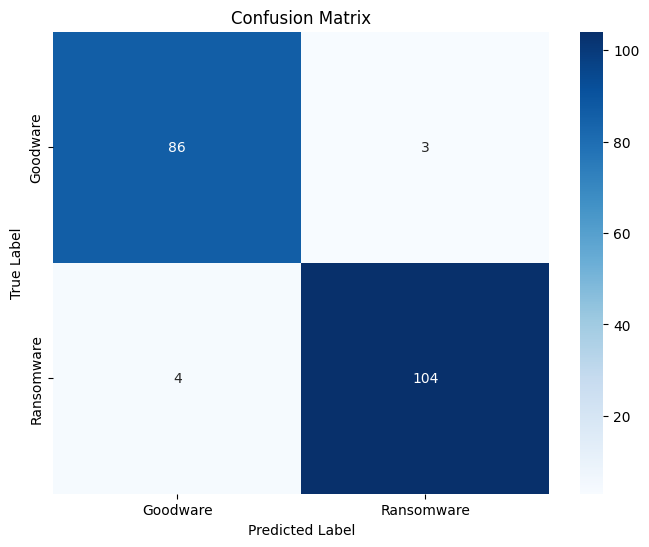

In [52]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Goodware', 'Ransomware'], yticklabels=['Goodware', 'Ransomware'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

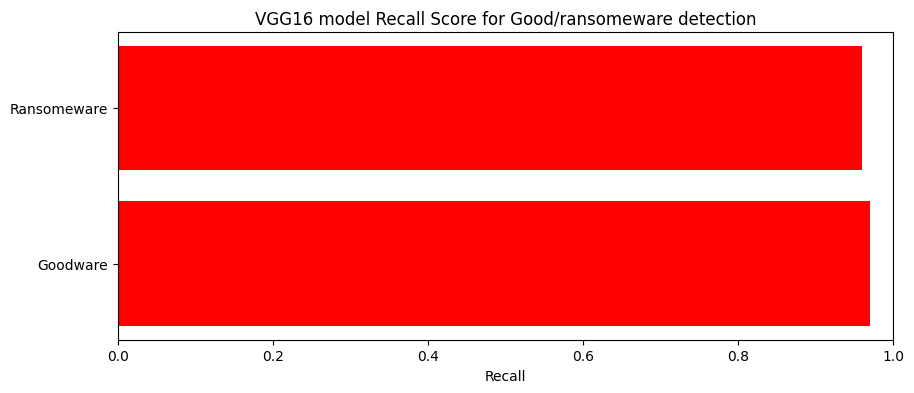

In [53]:
lines = classification_report(y_true, y_pred_labels).split('\n')
recall_scores = [float(line.split()[2]) for line in lines[2:4]]

plt.figure(figsize=(10, 4))
plt.barh(['Goodware','Ransomeware'], recall_scores, color='red')
plt.xlabel('Recall')
plt.title('VGG16 model Recall Score for Good/ransomeware detection')
plt.xlim(0, 1)  # Set x-axis limit to ensure consistency
plt.show()